In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
import tqdm
import re
import os
import glob
import spectres
from astropy import units as u

%matplotlib inline

In [26]:
SPS_HOME = os.path.abspath(os.path.join(os.getcwd(), '..'))
# SPS_HOME = os.getenv('SPS_HOME')
# SPS_HOME = SPS_HOME.replace('fsps', 'fsps_dev')  # -> I call my development folder for fsps 'fsps_dev' to keep it separate from my working fsps installation

print(SPS_HOME)

/Users/mreefe/Dropbox/Astrophysics/fsps_dev


In [27]:
# Define the teff, logg, and logz arrays that cover the grid of Brown+1996 models

teff_1 = np.arange(10000, 13000, 500)
teff_2 = np.arange(13000, 20000, 1000)
teff_3 = np.arange(20000, 30000, 2000)
teff_4 = np.arange(30000, 50000, 2500)
teff_5 = np.arange(50000, 120000, 5000)
teff_6 = np.arange(120000, 200000, 20000)
teff_7 = np.arange(200000, 250000+25000, 25000)
teff = np.concatenate((teff_1, teff_2, teff_3, teff_4, teff_5, teff_6, teff_7))
logt = np.log10(teff)

logg = np.arange(2., 8.75, 0.25)

logz = np.array([-2., -1., 0.])

print(logt)
print(logg)
print(logz)

[4.         4.0211893  4.04139269 4.06069784 4.07918125 4.09691001
 4.11394335 4.14612804 4.17609126 4.20411998 4.23044892 4.25527251
 4.2787536  4.30103    4.34242268 4.38021124 4.41497335 4.44715803
 4.47712125 4.51188336 4.54406804 4.57403127 4.60205999 4.62838893
 4.65321251 4.67669361 4.69897    4.74036269 4.77815125 4.81291336
 4.84509804 4.87506126 4.90308999 4.92941893 4.95424251 4.97772361
 5.         5.0211893  5.04139269 5.06069784 5.07918125 5.14612804
 5.20411998 5.25527251 5.30103    5.35218252 5.39794001]
[2.   2.25 2.5  2.75 3.   3.25 3.5  3.75 4.   4.25 4.5  4.75 5.   5.25
 5.5  5.75 6.   6.25 6.5  6.75 7.   7.25 7.5  7.75 8.   8.25 8.5 ]
[-2. -1.  0.]


In [28]:
# Define the wavelength grid that we will resample onto
# -> even logarithmic spacing by ~5% of the current wavelength
w_1 = 90. * 1.05**np.arange(0, int(np.log(800/90)/np.log(1.05))) 
# -> finer sampling in the FUV;
w_2 = np.arange(800., 1800., 0.2)
w_3 = np.arange(1800., 9000., 20.)
# -> spacing by ~5% of the current wavelength
w_4 = 9000. * 1.05**np.arange(0, int(np.log(9.99e6/9000)/np.log(1.05))) 

wavelength = np.concatenate((w_1, w_2, w_3, w_4))
print('w_1 = ', len(w_1))
print('w_2 = ', len(w_2))
print('w_3 = ', len(w_3))
print('w_4 = ', len(w_4))
print('length = ', len(wavelength))
print(wavelength)

w_1 =  44
w_2 =  5000
w_3 =  360
w_4 =  143
length =  5547
[9.00000000e+01 9.45000000e+01 9.92250000e+01 ... 8.33190634e+06
 8.74850165e+06 9.18592674e+06]


In [29]:
# wavelength must be in angstroms!
def airtovac(wavelength):
    # see: https://www.astro.uu.se/valdwiki/Air-to-vacuum%20conversion
    s = 1e4 / wavelength
    n = 1 + 0.00008336624212083 + 0.02408926869968 / (130.1065924522 - s**2) + 0.0001599740894897 / (38.92568793293 - s**2)
    # do not alter wavelengths below 2000 angstroms 
    wh = np.where(wavelength < 2000.)[0]
    n[wh] = 1.0
    return wavelength * n

In [30]:

# allocate a buffer for all of the spectra at one metallicity
library_in = np.zeros((len(wavelength), len(logt), len(logg), len(logz)))

for zi in range(len(logz)):
    zstr = ('z+' if logz[zi] >= 0.0 else 'z-') + '{:.2f}'.format(round(logz[zi], 1)).replace('.','').replace('-','')
    folder  = f'/Users/mreefe/Dropbox/Astrophysics/stellar_templates/brownspec_resamp/{zstr}'
    files = glob.glob(os.path.join(folder, '*'))

    for fpath in tqdm.tqdm(files):

        # parse the file name to get the temp, logg, and logz
        fname = os.path.basename(fpath)
        m = re.search(r'^T(\d+)g(\d+)z([-+]\d+).spec$', fname)
        teff_v = int(m.group(1))
        logg_v = int(m.group(2))/100
        logz_v = int(m.group(3))/100

        # find the indices corresponding to these values in the array
        logt_i = np.where(teff == teff_v)[0][0]
        logg_i = np.where(logg == logg_v)[0][0]

        # read in the text files
        wave_i, flux_i = np.loadtxt(fpath,  unpack=True)

        # perform the flux-conserving resampling onto the output wavelength grid
        # flux_o = spectres.spectres(wavelength, wave_i, flux_i, fill=0., verbose=False)
        flux_o = np.interp(wavelength, wave_i, flux_i, left=0., right=0.)

        # insert it into the 3D array
        library_in[:, logt_i, logg_i, zi] = flux_o

        # # plot the new and old spectrum to compare them
        # fig, ax = plt.subplots()
        # ax.plot(wave_i, flux_i)
        # ax.plot(wavelength, flux_o)
        # ax.set_xscale('log')
        # ax.set_yscale('log')
        # ax.set_xlabel('Wavelength (angstroms)')
        # ax.set_ylabel('Flambda')
        # # ax.set_xlim(900, 1800)
        # # ax.set_ylim(flux_i[(wave_i > 900) & (wave_i < 1800)].min()*0.98, flux_i[(wave_i > 900) & (wave_i < 1800)].max()*1.02)
        # plt.show()
        # plt.close()


100%|██████████| 499/499 [00:05<00:00, 93.02it/s] 


In [31]:
# Convert the units
c_ang = 299792458e10

for k in range(len(logz)):
    for i in range(len(logt)):
        for j in range(len(logg)):
            library_in[:,i,j,k] *= wavelength**2 / c_ang    # <= convert to erg/s/cm2/Hz
            library_in[:,i,j,k] *= 1/(4*np.pi)              # <= convert to Harvard flux
            # note: insofar as I can tell, FSPS stores its stellar libraries in flux moment or "Harvard flux" units, 
            #       which are off from physical flux units by a factor of 4pi.  See page 244-245 in 
            #       https://ads.harvard.edu/books/1989fsa..book/AbookC09.pdf for more info.
            #       Also see line 199 in getspec.f90 which does the conversion from these units into Lsun/Hz.


In [32]:
# Normalize to unity, to match the WMBasic grids
for k in range(len(logz)):
    for i in range(len(logt)):
        for j in range(len(logg)):
            mask = np.isfinite(library_in[:,i,j,k])
            norm = np.trapz(library_in[:,i,j,k][mask]*c_ang/wavelength[mask]**2, wavelength[mask])
            if norm > 0:
                library_in[:,i,j,k] /= norm

In [200]:
# Read in the ULLYSES templates
import pandas as pd
from astropy.io import fits

ul_library = np.zeros((len(wavelength), 0))         # <- ULLYSES spectra (each key is a different instrument)
# ul_error = np.zeros((len(wavelength), 0))           # <- error (only needed for coadding)
inst_library = np.zeros((len(wavelength), 0), dtype=int)   # <- identifier mask which saves which wavelength points belong to different instruments
grid_in = []                                               # <- input grid of ULLYSES star coordinates in (Teff,logg,logz) space

uldata = pd.read_csv('/Users/mreefe/Dropbox/Astrophysics/stellar_templates/ULLYSES_2025-05-15T16_31_18-04_00.csv', delimiter=',')
atmdata = np.loadtxt('/Users/mreefe/Dropbox/Astrophysics/stellar_templates/ullyses_atmosphere_parameters_feh.dat', delimiter=',', dtype=str)
hlspnames = np.array([name.lower() for name in uldata['target_name_hlsp'].to_numpy()])
ulnames = uldata['target_name_ullyses'].to_numpy()
for ulname,hlspname in zip(ulnames,hlspnames):
    if hlspname == 'v-vw-cha':
        hlspname = 'v-vw-chab'
        ulname = 'VW Cha B'

    # Get the atmospheric parameter data for this star (either measured or inferred by the spectral type / environment)
    wh = np.where([atmname.upper() == ulname.upper() for atmname in atmdata[:,0]])[0][0]
    ulteff = float(atmdata[wh,2])
    ullogg = float(atmdata[wh,3])
    ulfeh  = float(atmdata[wh,4])
    if ~np.isfinite(ulteff) | ~np.isfinite(ullogg) | ~np.isfinite(ulfeh):
        print(f'Skipping {ulname} as there are no atmospheric parameters.')
        continue
    if ulteff < 10000:
        print(f'Skipping {ulname} because it has Teff < 10000 K')
        continue

    # Load in the spectrum for this star
    # ulfiles = glob.glob(f'/Users/mreefe/Dropbox/Astrophysics/stellar_templates/ULLYSES/*_{hlspname}_*/*.fits')
    ulfiles = glob.glob(f'/Users/mreefe/Dropbox/Astrophysics/stellar_templates/ULLYSES/abutt/*_{hlspname}_*/*fuse*.fits')
    # ulfiles = glob.glob(f'/Users/mreefe/Dropbox/Astrophysics/stellar_templates/ULLYSES/preview/*_{hlspname}_*/*.fits')
    for (iinst,ulfile) in enumerate(ulfiles):

        ulhdu = fits.open(ulfile)
        ulwave = ulhdu[1].data['WAVELENGTH'][0,:].astype(np.float64)
        ulflux = ulhdu[1].data['FLUX'][0,:].astype(np.float64)
        ulerr = ulhdu[1].data['ERROR'][0,:].astype(np.float64)
        ulhdu.close()

        # Resample onto the same wavelength grid as the Brown models
        # ulflux_o = np.interp(wavelength, ulwave, ulflux, left=0., right=0.)
        # ulerr_o = np.interp(wavelength, ulwave, ulerr, left=0., right=0.)
        # ulflux_o, ulerr_o = spectres.spectres(wavelength, ulwave, ulflux, ulerr, fill=0., verbose=False)
        ulflux_o, ulerr_o = spectres.spectres_numba(wavelength, ulwave, ulflux, ulerr, fill=0., verbose=False)

        # Convert to per unit frequency units
        ulflux_o *= wavelength**2 / c_ang
        ulflux_o *= 1/(4*np.pi)
        ulerr_o *= wavelength**2 / c_ang
        ulerr_o *= 1/(4*np.pi)

        # Dont include spectra with no coverage at 1039-1055 angstroms
        if np.sum((ulwave > 1039) & (ulwave < 1055)) == 0:
            continue

        # NORMALIZE -- we are interpolating over these models, so they need to be normalized
        # so we're overweighting the closest stars and underweighting the furthest ones
        window = (wavelength >= ulwave.min()) & (wavelength <= ulwave.max())
        ulflux_o /= np.nanmedian(ulflux_o[window])
        ulerr_o /= np.nanmedian(ulflux_o[window])

        ulflux_o[~np.isfinite(ulflux_o)] = 0.
        ulerr_o[~np.isfinite(ulerr_o)] = 0.

        # First, save the wavelength coverage of this spectrum
        # goodwave = (ulwave[ulflux>0].min() < wavelength) & (wavelength < ulwave[ulflux>0].max())
        ul_library = np.concatenate((ul_library, ulflux_o.reshape((len(wavelength),1))), axis=1)
        grid_in.append((np.log10(ulteff), ullogg, ulfeh))

ul_logt = np.unique([gi[0] for gi in grid_in])
ul_logt.sort()
ul_logg = np.unique([gi[1] for gi in grid_in])
ul_logg.sort()
ul_logz = np.unique([gi[2] for gi in grid_in])
ul_logz.sort()
print(grid_in)
print(ul_logt)
print(ul_logg)
print(ul_logz)

Skipping AV 78 because it has Teff < 10000 K
Skipping AV 85 because it has Teff < 10000 K
Skipping DI91 719 as there are no atmospheric parameters.
Skipping Gaia DR3 4637562032451492608 as there are no atmospheric parameters.
Skipping Gaia DR3 4637562376048872448 as there are no atmospheric parameters.
Skipping DI91 739 as there are no atmospheric parameters.
Skipping DI91 842 as there are no atmospheric parameters.
Skipping PGMW 3070 as there are no atmospheric parameters.
Skipping NGC 1818 ROB D1 as there are no atmospheric parameters.
Skipping SK -69 106 because it has Teff < 10000 K
Skipping SK -68 73 because it has Teff < 10000 K
Skipping SK -66 97 as there are no atmospheric parameters.
Skipping SK -69 175 because it has Teff < 10000 K
Skipping SK -67 197 because it has Teff < 10000 K
Skipping SK -69 220 because it has Teff < 10000 K
Skipping ST92 5-31 because it has Teff < 10000 K
Skipping BAT99 127 because it has Teff < 10000 K
Skipping J095921.90+304518.1 as there are no atmos

/var/folders/_d/811k0zw90qn5rglh8sn17ryr0000gn/T/ipykernel_75443/1380979997.py:62: RuntimeWarning: divide by zero encountered in divide
  ulflux_o /= np.nanmedian(ulflux_o[window])
/var/folders/_d/811k0zw90qn5rglh8sn17ryr0000gn/T/ipykernel_75443/1380979997.py:62: RuntimeWarning: invalid value encountered in divide
  ulflux_o /= np.nanmedian(ulflux_o[window])


In [201]:
print(ul_library.shape)

(5547, 155)


155
[(4.306167591572845, 2.6, -0.6989700043360187), (4.626340367375042, 4.1, -0.6989700043360187), (4.589670402034894, 3.7, -0.6989700043360187), (4.277609214304091, 4.21, -0.6989700043360187), (4.278753600952829, 2.35, -0.6989700043360187), (4.549003262025788, 3.71, -0.6989700043360187), (4.63748972951251, 4.11, -0.6989700043360187), (4.57978359661681, 4.3, -0.6989700043360187), (4.565847818673518, 3.93, -0.6989700043360187), (4.560803001993964, 3.55, -0.6989700043360187), (4.528273777167044, 3.54, -0.6989700043360187), (4.56466606425209, 3.75, -0.6989700043360187), (4.565847818673518, 3.81, -0.6989700043360187), (4.599337132992489, 3.79, -0.6989700043360187), (4.556302500767287, 3.24, -0.6989700043360187), (4.575476508601899, 3.67, -0.6989700043360187), (4.365300748637988, 2.75, -0.6989700043360187), (4.423245873936808, 3.05, -0.6989700043360187), (4.63748972951251, 4.11, -0.6989700043360187), (4.440909082065217, 3.39, -0.6989700043360187), (4.418135498425232, 3.41, -0.69897000433601

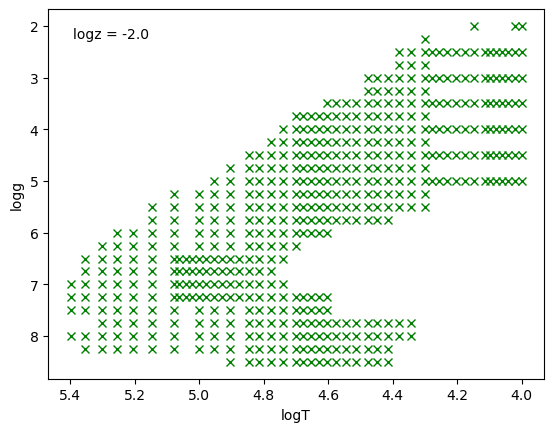

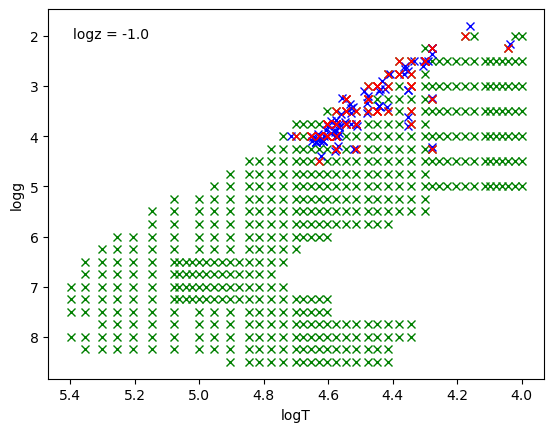

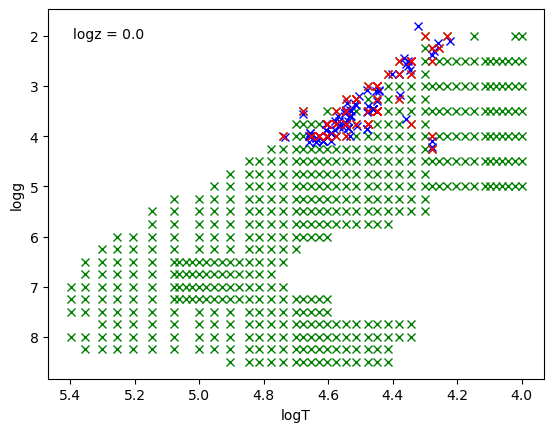

In [202]:
# Get the output grid by finding the points in the Brown grid closest to the (highly irregular) ULLYSES grid
logt_flat, logg_flat, logz_flat = np.meshgrid(logt, logg, logz, indexing='ij')
logt_flat = logt_flat.ravel()
logg_flat = logg_flat.ravel()
logz_flat = logz_flat.ravel()

logt_flat_coord, logg_flat_coord, logz_flat_coord = np.meshgrid(np.arange(len(logt)), np.arange(len(logg)), np.arange(len(logz)), indexing='ij')
logt_flat_coord = logt_flat_coord.ravel()
logg_flat_coord = logg_flat_coord.ravel()
logz_flat_coord = logz_flat_coord.ravel()

wh5000 = np.argmin(np.abs(wavelength - 5000.))

grid_out = []
grid_out_coord = []
for gridpt in grid_in:
    ullogt, ullogg, ulfeh = gridpt
    wh = np.argmin(np.abs(ullogt - logt_flat) + np.abs(ullogg - logg_flat) + np.abs(ulfeh - logz_flat))
    grid_out.append((logt_flat[wh], logg_flat[wh], logz_flat[wh]))
    grid_out_coord.append((logt_flat_coord[wh], logg_flat_coord[wh], logz_flat_coord[wh]))

    # also get neighboring points

    # candidate = (logt[max(logt_flat_coord[wh]-1,0)], logg_flat[wh], logz_flat[wh])
    # candidate_coord = (max(logt_flat_coord[wh]-1,0), logg_flat_coord[wh], logz_flat_coord[wh])
    # grid_extra.append(candidate)
    # grid_extra_coord.append(candidate_coord)

    # candidate = (logt[min(logt_flat_coord[wh]+1,len(logt)-1)], logg_flat[wh], logz_flat[wh])
    # candidate_coord = (min(logt_flat_coord[wh]+1,len(logt)-1), logg_flat_coord[wh], logz_flat_coord[wh])
    # grid_extra.append(candidate)
    # grid_extra_coord.append(candidate_coord)

    # candidate = (logt_flat[wh], logg[min(logg_flat_coord[wh]+1,len(logg)-1)], logz_flat[wh])
    # candidate_coord = (logt_flat_coord[wh], min(logg_flat_coord[wh]+1,len(logg)-1), logz_flat_coord[wh])
    # grid_extra.append(candidate)
    # grid_extra_coord.append(candidate_coord)

    # candidate = (logt_flat[wh], logg[max(logg_flat_coord[wh]-1,0)], logz_flat[wh])
    # candidate_coord = (logt_flat_coord[wh], max(logg_flat_coord[wh]-1,0), logz_flat_coord[wh])
    # grid_extra.append(candidate)
    # grid_extra_coord.append(candidate_coord)

grid_extra = list(zip(logt_flat, logg_flat, logz_flat))
grid_extra_coord = list(zip(logt_flat_coord, logg_flat_coord, logz_flat_coord))
i_to_remove = []
for i in range(len(grid_extra)):
    # prune grid points where there's no data
    if not (library_in[wh5000,grid_extra_coord[i][0],grid_extra_coord[i][1],grid_extra_coord[i][2]] > 0):
        i_to_remove.append(i)
    # # also prune grid points that are outside the extreme limits of all the input grids
    # for goc in grid_out_coord:
    #     if (grid_extra_coord[i][0] == goc[0]) and (grid_extra_coord[i][1] == goc[1]) and (grid_extra_coord[i][2] == goc[2]):
    #         i_to_remove.append(i)
    # if (grid_extra[i][0] > ul_logt.max()) or (grid_extra[i][0] < ul_logt.min()) or \
    #    (grid_extra[i][1] > ul_logg.max()) or (grid_extra[i][1] < ul_logg.min()):
        # i_to_remove.append(i)

grid_extra = [go for i,go in enumerate(grid_extra) if i not in i_to_remove]
grid_extra_coord = [goc for i,goc in enumerate(grid_extra_coord) if i not in i_to_remove]

print(len(grid_in))
print(grid_in)
print(len(grid_out))
print(grid_out)
print(grid_out_coord)
print(len(grid_extra))
print(grid_extra)
print(grid_extra_coord)

# Simple Teff/logg plot showing parameter space coverage
for zi in range(len(logz)):
    fig, ax = plt.subplots()
    for i in range(len(grid_extra)):
        if grid_extra[i][2] == logz[zi]:
            ax.plot(grid_extra[i][0], grid_extra[i][1], 'gx')
    for i in range(len(grid_out)):
        if grid_out[i][2] == logz[zi]:
            ax.plot(grid_in[i][0], grid_in[i][1], 'bx')
            ax.plot(grid_out[i][0], grid_out[i][1], 'rx')
    # ax.plot([go[0] for go in grid_out], [go[1] for go in grid_out], 'rx')
    # ax.plot([gi[0] for gi in grid_in],  [gi[1] for gi in grid_in],  'bx')
    ax.annotate(f'logz = {logz[zi]}', (0.05, 0.95), ha='left', va='top', xycoords=ax.transAxes)
    ax.invert_xaxis()
    ax.invert_yaxis()
    ax.set_xlabel('logT')
    ax.set_ylabel('logg')
    plt.show()

In [203]:
# print(grid_in)

# # We need to...do the best that we can with what we have
# for i in range(len(grid_in)):
#     if grid_in[i][2] < -0.5:
#         grid_in[i] = (grid_in[i][0], grid_in[i][1], -1.0)
#     else:
#         grid_in[i] = (grid_in[i][0], grid_in[i][1], +0.0)

# print(grid_in)

In [204]:
# allocate an output array buffer
ullyses_out = np.zeros((len(wavelength), len(logt), len(logg), len(logz)))

for wi in tqdm.trange(len(wavelength)):

    if any(ul_library[wi, :] > 0.):
        # Step 1: Do a nearest-neighbor interpolation for the "base" set of points that are closest to the
        # actual data points
        ulout = interpolate.griddata(grid_in, ul_library[wi, :], grid_out, method='nearest', fill_value=0.)
        for k, gridpoint in enumerate(grid_out_coord):
            ullyses_out[wi, gridpoint[0], gridpoint[1], gridpoint[2]] = ulout[k]
    
        # step 2: do a linear interpolation for the "extra" points
        ulextra = interpolate.griddata(grid_out, ulout, grid_extra, method='linear', fill_value=0.)
        for k, gridpoint in enumerate(grid_extra_coord):
            ullyses_out[wi, gridpoint[0], gridpoint[1], gridpoint[2]] = ulextra[k]

# # -- no interpolation version ---
# ul_logt_flat = np.array([gi[0] for gi in grid_in])
# ul_logg_flat = np.array([gi[1] for gi in grid_in])
# ul_logz_flat = np.array([gi[2] for gi in grid_in])
# for k, gridpoint in enumerate(grid_out_coord):
#     logt_k, logg_k, logz_k = grid_out[k]
#     wh = np.nanargmin(np.abs(logt_k - ul_logt_flat) + np.abs(logg_k - ul_logg_flat) + np.abs(logz_k - ul_logz_flat))
#     ullyses_out[:, gridpoint[0], gridpoint[1], gridpoint[2]] += ul_library[:, wh]
#     window = ul_library[:, wh] > 0.
#     if np.sum(window) > 0:
#         ullyses_out[:, gridpoint[0], gridpoint[1], gridpoint[2]] /= np.nanmedian(ullyses_out[window, gridpoint[0], gridpoint[1], gridpoint[2]])

  0%|          | 0/5547 [00:00<?, ?it/s]

100%|██████████| 5547/5547 [00:13<00:00, 422.29it/s] 


In [205]:
# Extrapolate to get the logZ = -2 points
slope = (ullyses_out[:,:,:,1]-ullyses_out[:,:,:,2]) / (-1.)
dlogz = -1.
ullyses_out[:,:,:,0] = ullyses_out[:,:,:,1] + slope*dlogz

In [206]:
# # allocate an output array buffer
# ullyses_err_out = np.zeros((len(wavelength), len(logt), len(logg), len(logz), len(list(ul_library.keys()))))

# # Do a trilinear interpolation across the logt, logg, and logz axes
# for wi in tqdm.trange(len(wavelength)):

#     for iinst in ul_error.keys():
#         if any(ul_error[iinst][wi, :]) > 0:
#             ulerr = interpolate.griddata(grid_in, ul_error[iinst][wi, :], grid_out, method='linear', fill_value=0.)
#             for k, gridpoint in enumerate(grid_out_coord):
#                 ullyses_err_out[wi, gridpoint[0], gridpoint[1], gridpoint[2], iinst] = ulerr[k]

In [207]:
# -- fill in missing grid points on the Brown models ---
LOGT, LOGG, LOGZ = np.meshgrid(logt, logg, logz, indexing='ij')
LOGT_C, LOGG_C, LOGZ_C = np.meshgrid(np.arange(len(logt)), np.arange(len(logg)), np.arange(len(logz)), indexing='ij')
points_with_data = library_in[wh5000,:,:,:] > 0.
logt_with_data = LOGT[points_with_data]
logg_with_data = LOGG[points_with_data]
logz_with_data = LOGZ[points_with_data]
logt_coord_with_data = LOGT_C[points_with_data]
logg_coord_with_data = LOGG_C[points_with_data]
logz_coord_with_data = LOGZ_C[points_with_data]

for k, gridpoint in enumerate(grid_out_coord):
    if points_with_data[gridpoint[0],gridpoint[1],gridpoint[2]]:
        continue
    print(f'Filling in grid point at {grid_out[k]}')
    logt_k, logg_k, logz_k = grid_out[k]
    wh = np.nanargmin(np.abs(logt_k - logt_with_data) + np.abs(logg_k - logg_with_data) + np.abs(logz_k - logz_with_data))
    library_in[:, gridpoint[0], gridpoint[1], gridpoint[2]] = library_in[:, logt_coord_with_data[wh], logg_coord_with_data[wh], logz_coord_with_data[wh]]

# for k, gridpoint in enumerate(grid_extra_coord):
#     if points_with_data[gridpoint[0],gridpoint[1],gridpoint[2]]:
#         continue
#     logt_k, logg_k, logz_k = grid_extra[k]
#     wh = np.nanargmin(np.abs(logt_k - logt_with_data) + np.abs(logg_k - logg_with_data) + np.abs(logz_k - logz_with_data))
#     library_in[:, gridpoint[0], gridpoint[1], gridpoint[2]] = library_in[:, logt_coord_with_data[wh], logg_coord_with_data[wh], logz_coord_with_data[wh]]

In [ ]:
instrument = np.zeros((len(wavelength), len(logt), len(logg), len(logz)), dtype=int)
# library_out = np.zeros(library_in.shape)
library_out = np.copy(library_in)
ul_data = np.zeros((len(logt), len(logg), len(logz)), dtype=bool)

# Now we need to stitch the N grids together
for k,gridpoint in enumerate(np.concatenate((grid_out_coord, grid_extra_coord))):
    xi,yi,zi = gridpoint

    # iterate over each instrument
    f_gridpt = np.zeros(len(wavelength))
    e_gridpt = np.zeros(len(wavelength))

    wavegood = ullyses_out[:,xi,yi,zi] != 0.
    waveuse  = ((wavelength >= 1039.) & (wavelength <= 1070.)) | ((wavelength >= 955.) & (wavelength <= 968.))
    if np.sum(wavegood & waveuse) == 0:
        continue

    # wmin = wavelength[wavegood].min()
    # wmax = wavelength[wavegood].max()
    # we need to rescale because the ULLYSES data are observed flux, but what we need is the flux at the surface of the star
    # scale = np.trapz(library_in[wavegood,xi,yi,zi], wavelength[wavegood]) / \
    #         np.trapz(ullyses_out[wavegood,xi,yi,zi], wavelength[wavegood])
    scale = np.nanmedian(library_in[wavegood,xi,yi,zi]) / np.nanmedian(ullyses_out[wavegood,xi,yi,zi])
    library_out[:,xi,yi,zi] = library_in[:,xi,yi,zi]

    library_out[wavegood&waveuse,xi,yi,zi] = ullyses_out[wavegood&waveuse,xi,yi,zi]*scale
    ul_data[xi,yi,zi] = True


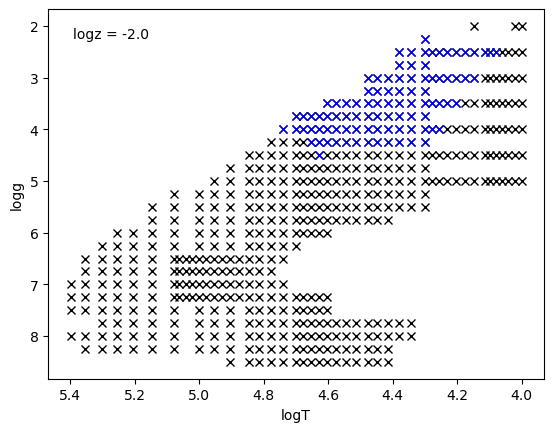

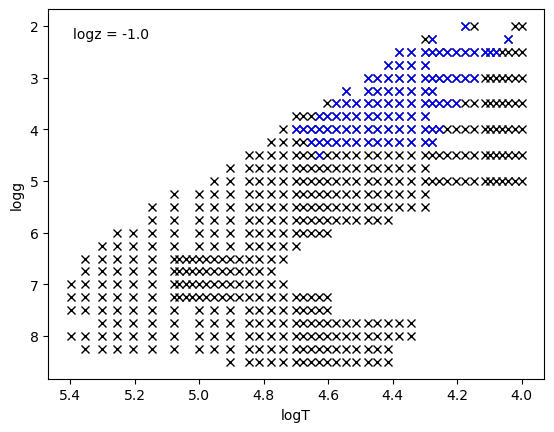

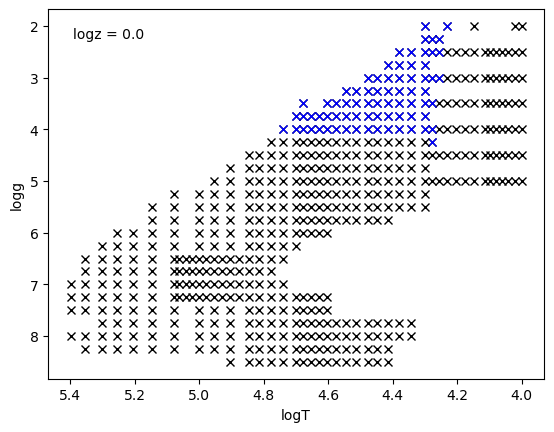

In [241]:
for lzi in range(len(logz)):
    fig, ax = plt.subplots()
    for lti in range(len(logt)):
        for lgi in range(len(logg)):
            if library_out[wh5000,lti,lgi,lzi] > 0:
                ax.plot(logt[lti], logg[lgi], 'kx')
            if ul_data[lti,lgi,lzi]:
                ax.plot(logt[lti], logg[lgi], 'bx')
    ax.annotate(f'logz = {logz[lzi]}', (0.05, 0.95), ha='left', va='top', xycoords=ax.transAxes)
    ax.invert_xaxis()
    ax.invert_yaxis()
    ax.set_xlabel('logT')
    ax.set_ylabel('logg')
    plt.show()

In [242]:
# # Delete models in the region of the ULLYSES coverage that don't actually have spectra
# for lti in range(len(logt)):
#     for lgi in range(len(logg)):
#         for lzi in range(len(logz)):
#             if ul_data[lti,lgi,lzi]:
#                 continue
#             if (logt[lti] >= 4.0) and (logt[lti] <= ul_logt.max()) and \
#                (logg[lgi] >= 1.5) and (logg[lgi] <= 4.5):
#                 print(f'Removing template at ({lti},{lgi},{lzi})')
#                 library_out[:,lti,lgi,lzi] = 0.

0
20000.000000000004 2.5 -1.0
AV 104


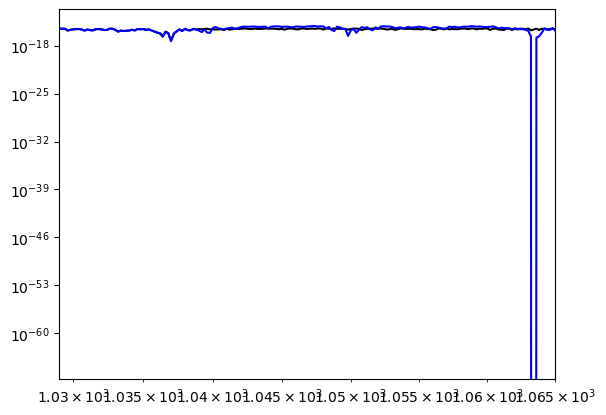

In [243]:
# Preview some resampled spectra
for i in range(len(grid_out)):   
    # print(np.trapz(library_in[:,grid_out_coord[i][0],grid_out_coord[i][1],grid_out_coord[i][2]]*c_ang/wavelength**2, wavelength))
    if any(ullyses_out[:,grid_out_coord[i][0],grid_out_coord[i][1],grid_out_coord[i][2]] > 0):
        print(i)
        print(10**grid_out[i][0], grid_out[i][1], grid_out[i][2])
        print(ulnames[np.nanargmin(np.abs(grid_out[i][0] - [gi[0] for gi in grid_in]) + 
                                np.abs(grid_out[i][1] - [gi[1] for gi in grid_in]) + 
                                np.abs(grid_out[i][2] - [gi[2] for gi in grid_in]))])
        fig, ax = plt.subplots()
        # ax.loglog(wavelength, ullyses_out[:,grid_out_coord[i][0],grid_out_coord[i][1],grid_out_coord[i][2]], 'r-')
        ax.loglog(wavelength, library_in[:,grid_out_coord[i][0],grid_out_coord[i][1],grid_out_coord[i][2]], 'k-')
        ax.loglog(wavelength, library_out[:,grid_out_coord[i][0],grid_out_coord[i][1],grid_out_coord[i][2]], 'b-')
        # ax.loglog(wavelength, ullyses_out[:,grid_out_coord[i][0],grid_out_coord[i][1],grid_out_coord[i][2],1], 'c-')
        # ax.loglog(wavelength, ullyses_out[:,grid_out_coord[i][0],grid_out_coord[i][1],grid_out_coord[i][2],2], 'g-')
        # ax.loglog(wavelength, ullyses_out[:,grid_out_coord[i][0],grid_out_coord[i][1],grid_out_coord[i][2],3], 'c-')
        # ax.loglog(wavelength, ullyses_out[:,grid_out_coord[i][0],grid_out_coord[i][1],grid_out_coord[i][2],4], 'm-')
        # ax.loglog(wavelength, ullyses_out[:,grid_out_coord[i][0],grid_out_coord[i][1],grid_out_coord[i][2],5], 'y-')
        # ax.loglog(wavelength, ullyses_out[:,grid_out_coord[i][0],grid_out_coord[i][1],grid_out_coord[i][2],6], '-', color='brown')
        # ax.loglog(wavelength, ullyses_out[:,grid_out_coord[i][0],grid_out_coord[i][1],grid_out_coord[i][2],7], '-', color='orange')
        ax.set_xlim(1029,1065)
        # ax.set_ylim(0, 1e-15)
        plt.show()
        break

In [244]:
library_out.shape

(5547, 47, 27, 3)

In [245]:
# Save as a text file with the same format as the format 
for zi,logzi in enumerate(logz):
    zsun = 0.0134
    z = 10**logzi * zsun
    # need to flatten the array to 2D matching the shape of the WM-Basic arrays FSPS uses
    # (flatten logt and logg axis, should be ordered as [t1_g1 t2_g1 t3_g1 ... t1_g2 t2_g2 t3_g2 ...])
    library_outpt = library_out[:,:,:,zi].reshape(library_out.shape[0], len(logg)*len(logt), order='F')
    # append the wavelength column
    library_outpt = np.concatenate((wavelength.reshape(len(wavelength), 1), library_outpt), axis=1)

    np.savetxt(os.path.join(SPS_HOME, f'SPECTRA/Hot_spectra/Brown1996/Brown1996z{z:.4f}.spec'), library_outpt, fmt='%.4e', delimiter=' ')

In [246]:
print(SPS_HOME)

/Users/mreefe/Dropbox/Astrophysics/fsps_dev


In [247]:
# save other ancillary files
np.savetxt(os.path.join(SPS_HOME, 'SPECTRA/Hot_spectra/Brown1996/Brown1996.teff'), logt, fmt='%13.5f')
np.savetxt(os.path.join(SPS_HOME, 'SPECTRA/Hot_spectra/Brown1996/Brown1996.logg'), logg, fmt='%13.5f')
np.savetxt(os.path.join(SPS_HOME, 'SPECTRA/Hot_spectra/Brown1996/Brown1996_zlegend.dat'), 10**logz*zsun, fmt='%7.4f')